In [2]:
!pip install scikit-optimize

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 930.9 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.6/806.6 kB 3.7 MB/s eta 0:00:00a 0:00:01


In [1]:
# Imports principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from skimage.io import imread
from skimage.transform import resize
import warnings

# Modelos y métricas
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.pipeline import Pipeline

# --- CLASIFICADORES ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# --- OPTIMIZACIÓN BAYESIANA (skopt) ---
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# Ignorar advertencias de convergencia para limpieza
warnings.filterwarnings("ignore")

In [2]:
# Función para cargar imágenes
def load_image_dataset(root_dir, size=(64,64), max_per_class=None):
    X, y = [], []
    if not os.path.exists(root_dir):
        print(f"Error: La carpeta '{root_dir}' no existe.")
        return np.array([]), np.array([]), []
        
    classes = sorted(os.listdir(root_dir))
    for cls in classes:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path): continue
        
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if max_per_class: files = files[:max_per_class]
        
        for f in files:
            try:
                img = imread(os.path.join(cls_path, f))
                if img.ndim == 3: img = img[...,0] # Grayscale
                img_resized = resize(img, size, anti_aliasing=True)
                X.append(img_resized)
                y.append(cls)
            except: pass
    return np.array(X), np.array(y), classes

In [3]:
# Carga
X, y, classes = load_image_dataset("CMS_data", size=(64,64))
print("Datos cargados.")
print(f"Clases detectadas: {classes}")

# 1. Codificar etiquetas (String -> Int) para evitar errores en ANN
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Datos cargados.
Clases detectadas: ['electron', 'muon', 'neutrino', 'proton', 'quark', 'tau']


In [4]:
# Normalizar
X = X / X.max()

# Aplanar para modelos clásicos (RF, SVM, KNN, ANN MLP)
X_flat = X.reshape(len(X), -1)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (48000, 4096), Test: (12000, 4096)


In [5]:
# Binarizar etiquetas para ROC
y_test_bin = label_binarize(y_test, classes=range(len(classes)))
n_classes = y_test_bin.shape[1]

In [6]:
# --- Función para graficar ROC ---
def plot_multiclass_roc(y_test_bin, y_score, classes, title):
    plt.figure(figsize=(8,6))
    for i in range(len(classes)):
        if np.sum(y_test_bin[:, i]) > 0: # Evita error si falta una clase en el split
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

In [7]:
# --- Función para graficar Curvas de Aprendizaje ---
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None: plt.ylim(*ylim)
    plt.xlabel("Ejemplos de entrenamiento")
    plt.ylabel("Score (Accuracy)")
    
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="accuracy"
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True)
    plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r", label="Score de Entrenamiento (Train)")
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g", label="Score de Validación (Test/CV)")
    plt.legend(loc="best")
    plt.show()

In [8]:
print("--- Iniciando BayesSearchCV para Random Forest ---")

# Pipeline
pipe_rf = Pipeline([
    ('scaler', StandardScaler()), # Aunque RF no lo exige, es buena práctica si se comparan modelos
    ('clf', RandomForestClassifier(random_state=42))
])

# Espacio de búsqueda (Bayesiano usa Integer/Categorical en lugar de randint)
search_space_rf = {
    'clf__n_estimators': Integer(50, 300),
    'clf__max_depth': Integer(5, 50),
    'clf__min_samples_split': Integer(2, 10),
    'clf__criterion': Categorical(['gini', 'entropy'])
}

# BayesSearchCV
opt_rf = BayesSearchCV(
    pipe_rf, 
    search_space_rf, 
    n_iter=15, # Número de iteraciones de optimización
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1, 
    random_state=42,
    verbose=0
)
opt_rf.fit(X_train, y_train)

best_rf = opt_rf.best_estimator_
print(f"Mejores parámetros RF: {opt_rf.best_params_}")

--- Iniciando BayesSearchCV para Random Forest ---
Mejores parámetros RF: OrderedDict([('clf__criterion', 'gini'), ('clf__max_depth', 50), ('clf__min_samples_split', 2), ('clf__n_estimators', 300)])


In [9]:
print("--- Reporte de Clasificación (Random Forest - BO) ---")
y_pred_rf = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=classes))

--- Reporte de Clasificación (Random Forest - BO) ---
              precision    recall  f1-score   support

    electron       0.67      0.52      0.58      2000
        muon       0.51      0.51      0.51      2000
    neutrino       0.75      0.76      0.75      2000
      proton       0.98      1.00      0.99      2000
       quark       0.91      1.00      0.95      2000
         tau       0.74      0.81      0.78      2000

    accuracy                           0.77     12000
   macro avg       0.76      0.77      0.76     12000
weighted avg       0.76      0.77      0.76     12000



--- Matriz de Confusión ---


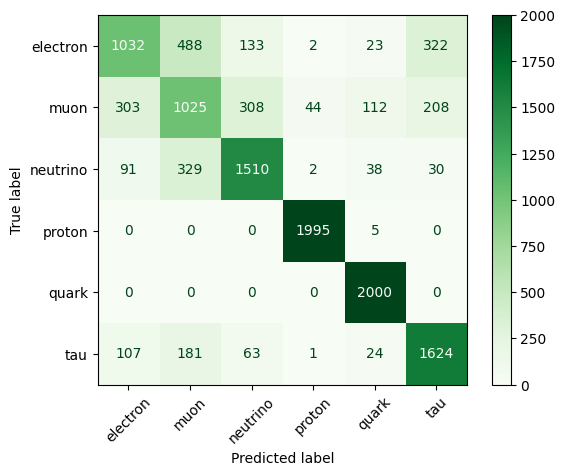

In [10]:
print("--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(cmap="Greens", xticks_rotation=45)
plt.show()

--- Precisión por Clase ---


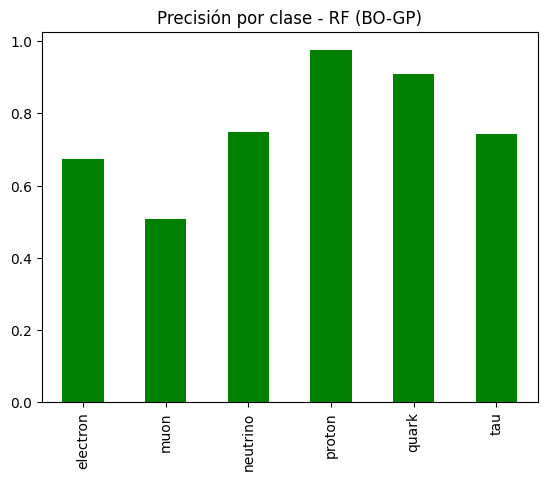

In [11]:
print("--- Precisión por Clase ---")
report_rf = classification_report(y_test, y_pred_rf, output_dict=True, target_names=classes)
pd.DataFrame(report_rf).transpose().loc[classes, "precision"].plot(kind="bar", color="green")
plt.title("Precisión por clase - RF (BO-GP)"); plt.show()

--- Curvas ROC ---


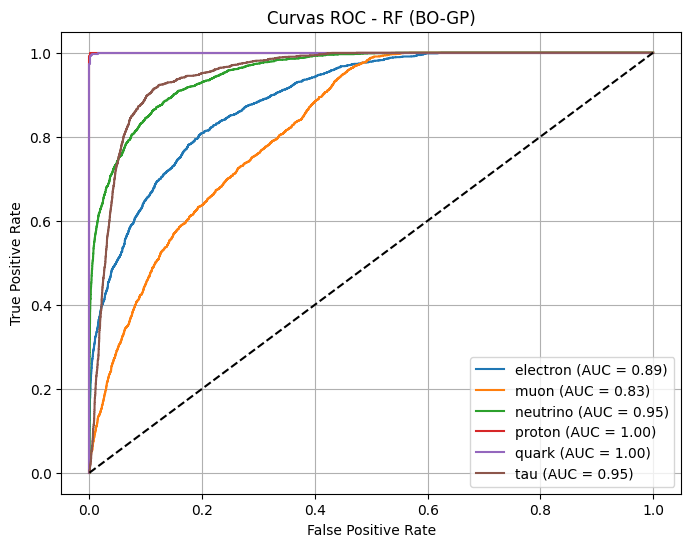

In [12]:
print("--- Curvas ROC ---")
y_score_rf = best_rf.predict_proba(X_test)
plot_multiclass_roc(y_test_bin, y_score_rf, classes, "Curvas ROC - RF (BO-GP)")

--- Curva de Aprendizaje ---


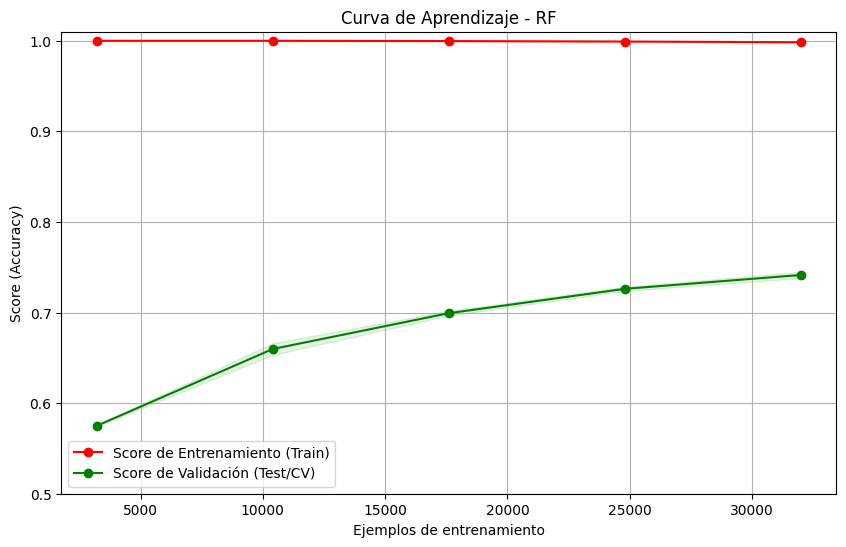

In [13]:
print("--- Curva de Aprendizaje ---")
plot_learning_curve(best_rf, "Curva de Aprendizaje - RF", X_train, y_train, cv=3, ylim=(0.5, 1.01))